## Areas of interest

Simple visualization of the candidate area of interest in a World map.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import pathlib
import os

sys.path.append(os.path.abspath(".."))

In [3]:
import geodatasets
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

from src.config import load_config
from src.io import GLOBAL_CONFIG

In [4]:
cfg = load_config(GLOBAL_CONFIG)

In [5]:
aois = cfg.aoi.candidates
aois

{'andalusia': [-6.0805, 37.2323],
 'brandeburg': [13.4402, 52.7654],
 'lombardy': [10.0509, 45.6435]}

In [6]:
world = gpd.read_file(geodatasets.get_path("naturalearth land"))

In [7]:
aoi_points = {
    "points": {},
    "lon": [],
    "lat": [],
}
for name, coords in aois.items():
    p = Point(coords)
    aoi_points["points"][name] = p
    aoi_points["lon"].append(p.x)
    aoi_points["lat"].append(p.y)

In [8]:
aoi_points

{'points': {'andalusia': <POINT (-6.08 37.232)>,
  'brandeburg': <POINT (13.44 52.765)>,
  'lombardy': <POINT (10.051 45.644)>},
 'lon': [-6.0805, 13.4402, 10.0509],
 'lat': [37.2323, 52.7654, 45.6435]}

In [9]:
min(aoi_points["lat"]), max(aoi_points["lat"])

(37.2323, 52.7654)

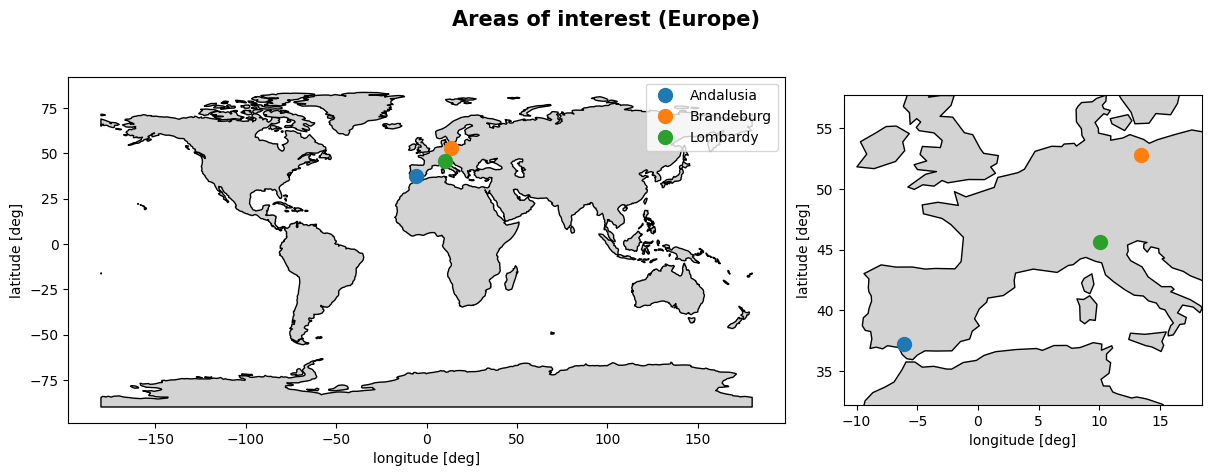

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6), gridspec_kw = {"width_ratios": [2] + [1]}, constrained_layout=True)

# First image
world.plot(ax=ax[0], color="lightgray", edgecolor="black")
for name, p in aoi_points["points"].items():
    ax[0].plot(p.x, p.y, "o", markersize=10, label=name.title()) 
ax[0].legend()
ax[0].set_xlabel("longitude [deg]")
ax[0].set_ylabel("latitude [deg]")

# Second image
world.plot(ax=ax[1], color="lightgray", edgecolor="black")
for name, p in aoi_points["points"].items():
    ax[1].plot(p.x, p.y, "o", markersize=10, label=name.title()) 
margin = 5
ax[1].set_ylim(min(aoi_points["lat"])-margin, max(aoi_points["lat"])+margin)
ax[1].set_xlim(min(aoi_points["lon"])-margin, max(aoi_points["lon"])+margin)
ax[1].set_xlabel("longitude [deg]")
ax[1].set_ylabel("latitude [deg]")

_ = fig.suptitle(
    f"Areas of interest (Europe)",
    fontsize=15,
    fontweight="bold",
    y=0.9
)

fig.savefig("../assets/aois.png")